# **Métodos ensemble**


Profesor: **D.Sc. Pastor Enmanuel Pérez Estigarribia**

**CONTENIDO**

1.   Métodos voting, bagging, boosting, stacking.
2.   Aplicación de métodos ensemble con Python.

**OBJETIVOS:**


**Conceptuales**

Entender el funcionamiento de los métodos ensemble.

**Procedimentales:**

Aplicar métodos ensemble empleando Python.

**Actitudinales:**

Aprovechar las capacidades de Python para aplicar métodos ensemble.

# [**Stacking Ensemble con Python**](https://machinelearningmastery.com/stacking-ensemble-machine-learning-with-python/)

Utiliza un algoritmo de metaaprendizaje para aprender a combinar mejor las predicciones de dos o más algoritmos básicos de aprendizaje automático.

**Formulación del problema:**

Dados múltiples modelos de aprendizaje automático que son hábiles en un problema, pero de diferentes maneras, ¿cómo eligir qué modelo usar?

- A diferencia del Bagging, en el Stacking, los modelos suelen ser diferentes (p. ej., no todos los árboles de decisión) y se ajustan al mismo conjunto de datos (p. ej., en lugar de muestras del conjunto de datos de entrenamiento).
- A diferencia del boosting, en el Stacking, se usa un solo modelo para aprender cómo combinar mejor las predicciones de los modelos contribuyentes (por ejemplo, en lugar de una secuencia de modelos que corrigen las predicciones de modelos anteriores).

La arquitectura de un modelo de Stacking implica dos o más modelos base, a menudo denominados modelos de nivel 0, y un metamodelo que combina las predicciones de los modelos base, denominado modelo de nivel 1.

Modelos de nivel 0 ( Base-Models ) : modelos que se ajustan a los datos de entrenamiento y cuyas predicciones se compilan.
Modelo de nivel 1 ( metamodelo ) : modelo que aprende a combinar mejor las predicciones de los modelos base.

<img src='https://rasbt.github.io/mlxtend/user_guide/classifier/StackingClassifier_files/stackingclassification_overview.png'>

Fuente: https://rasbt.github.io/mlxtend/user_guide/classifier/StackingClassifier/


<img src='https://www.scaler.com/topics/images/architecture-of-a-stacking-model.webp'>

Fuente: https://www.scaler.com/topics/machine-learning/stacking-in-machine-learning/

A continuación se muestra la arquitectura de un modelo de apilamiento en el aprendizaje automático:

**Conjunto de datos :** el conjunto de datos en el que trabajamos. Este conjunto de datos se divide en datos de entrenamiento y de prueba .

**Modelos de nivel 0 :** estos son modelos basados ​​en predicciones.

**Predicción de nivel 0 :** la predicción resultante de los modelos anteriores es la predicción de nivel 0 . Esto se basa en los datos de entrenamiento.

**Modelo de nivel 1 :** este es el modelo que combina la predicción de todos los modelos de nivel 0 o base . También se le conoce como metamodelo .

**Predicción de nivel 1 :** el modelo de nivel 1 se entrena en múltiples predicciones dadas por varios modelos base y luego integra de manera óptima las predicciones de los modelos base en los datos de prueba.


## **API Scikit-Learn de Stacking**

Vea aquí [Cómo implementar la generalización apilada (apilamiento) desde cero con Python](https://machinelearningmastery.com/implementing-stacking-scratch-python/)

El Stacking se proporciona a través de las clases StackingRegressor y StackingClassifier .

In [ ]:
# compare standalone models for binary classification
from numpy import mean
from numpy import std
from sklearn.ensemble import StackingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from matplotlib import pyplot

Se proporciona una lista de modelos de nivel 0 o modelos base a través del argumento "estimators". Esta es una lista de Python donde cada elemento de la lista es una tupla con el nombre del modelo y la instancia del modelo configurado.

In [ ]:
models = [('lr',LogisticRegression()),('svm',SVC())]
stacking = StackingClassifier(estimators=models)

Cada modelo de la lista también puede ser un Pipeline , incluida cualquier preparación de datos requerida por el modelo antes de ajustar el modelo en el conjunto de datos de entrenamiento. Por ejemplo:

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
models = [('lr',LogisticRegression()),('svm',make_pipeline(StandardScaler(),SVC()))]
stacking = StackingClassifier(estimators=models)

#### **Stacking para clasificación**

Evaluaremos los siguientes cinco algoritmos:

- Regresión logística.
- k-Vecinos más cercanos.
- Árbol de decisión.
- Support Vector Machine.
- Naive Bayes.

Un ejemplo completo se muestra a continuación


>lr 0.866 (0.029)
>knn 0.931 (0.025)
>cart 0.827 (0.043)
>svm 0.957 (0.020)
>bayes 0.833 (0.031)


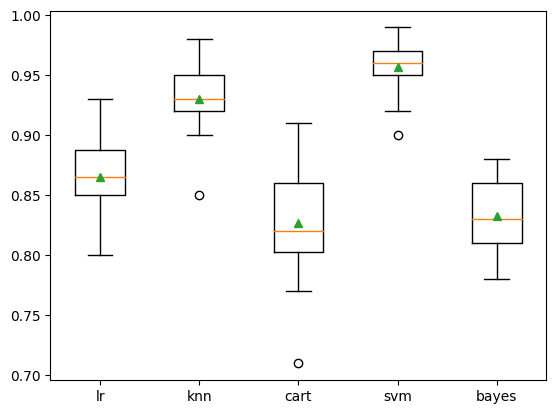

In [ ]:

# compare standalone models for binary classification
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=1)
 return X, y

# get a list of models to evaluate
def get_models():
 models = dict()
 models['lr'] = LogisticRegression()
 models['knn'] = KNeighborsClassifier()
 models['cart'] = DecisionTreeClassifier()
 models['svm'] = SVC()
 models['bayes'] = GaussianNB()
 return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 scores = evaluate_model(model, X, y)
 results.append(scores)
 names.append(name)
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

La función get_stacking() a continuación define el modelo StackingClassifier definiendo primero una lista de tuplas para los cinco modelos base y luego definiendo el metamodelo de regresión logística para combinar las predicciones de los modelos base usando una validación cruzada de 5 fold.

In [ ]:
# get a stacking ensemble of models
def get_stacking():
 # define the base models
 level0 = list()
 level0.append(('lr', LogisticRegression()))
 level0.append(('knn', KNeighborsClassifier()))
 level0.append(('cart', DecisionTreeClassifier()))
 level0.append(('svm', SVC()))
 level0.append(('bayes', GaussianNB()))
 # define meta learner model
 level1 = LogisticRegression()
 # define the stacking ensemble
 model = StackingClassifier(estimators=level0, final_estimator=level1, cv=5)
 return model

Podemos incluir el conjunto de stacking en la lista de modelos para evaluar, junto con los modelos independientes.

In [ ]:
# get a list of models to evaluate
def get_models():
 models = dict()
 models['lr'] = LogisticRegression()
 models['knn'] = KNeighborsClassifier()
 models['cart'] = DecisionTreeClassifier()
 models['svm'] = SVC()
 models['bayes'] = GaussianNB()
 models['stacking'] = get_stacking()
 return models

Un ejemplo completo de evaluación del modelo de stacking junto con los modelos independientes se muestra a continuación.

>lr 0.866 (0.029)
>knn 0.931 (0.025)
>cart 0.829 (0.044)
>svm 0.957 (0.020)
>bayes 0.833 (0.031)
>stacking 0.960 (0.022)


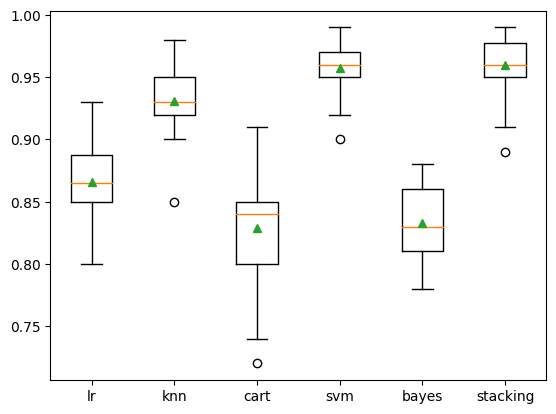

In [ ]:

# compare ensemble to each baseline classifier
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=1)
 return X, y

# get a stacking ensemble of models
def get_stacking():
 # define the base models
 level0 = list()
 level0.append(('lr', LogisticRegression()))
 level0.append(('knn', KNeighborsClassifier()))
 level0.append(('cart', DecisionTreeClassifier()))
 level0.append(('svm', SVC()))
 # define meta learner model
 level1 = LogisticRegression()
 # define the stacking ensemble
 model = StackingClassifier(estimators=level0, final_estimator=level1, cv=5)
 return model

# get a list of models to evaluate
def get_models():
 models = dict()
 models['lr'] = LogisticRegression()
 models['knn'] = KNeighborsClassifier()
 models['cart'] = DecisionTreeClassifier()
 models['svm'] = SVC()
 models['bayes'] = GaussianNB()
 models['stacking'] = get_stacking()
 return models

# evaluate a give model using cross-validation
def evaluate_model(model, X, y):
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 scores = evaluate_model(model, X, y)
 results.append(scores)
 names.append(name)
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

>stacking 0.964 (0.018)

## **Stacking para regresión**

La función get_stacking() a continuación define el modelo StackingRegressor definiendo primero una lista de tuplas para los tres modelos base y luego definiendo el metamodelo de regresión lineal para combinar las predicciones de los modelos base usando una validación cruzada de 5 fold.

Nuestra expectativa es que el conjunto de apilamiento funcione mejor que cualquier modelo base único.

Este no es siempre el caso, y si no es el caso, entonces el modelo base debe usarse a favor del modelo de conjunto.

El ejemplo completo de evaluación del modelo de conjunto de apilamiento junto con los modelos independientes se enumera a continuación.

>knn -101.019 (7.161)
>cart -149.185 (11.685)
>svm -162.419 (12.565)
>stacking -56.593 (5.457)


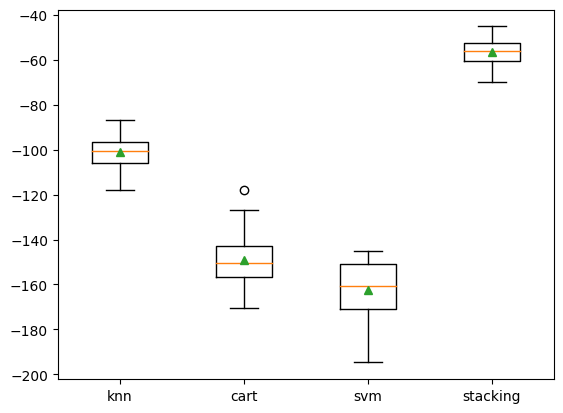

In [ ]:
# compare ensemble to each standalone models for regression
from numpy import mean
from numpy import std
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=1)
 return X, y

# get a stacking ensemble of models
def get_stacking():
 # define the base models
 level0 = list()
 level0.append(('knn', KNeighborsRegressor()))
 level0.append(('cart', DecisionTreeRegressor()))
 level0.append(('svm', SVR()))
 # define meta learner model
 level1 = LinearRegression()
 # define the stacking ensemble
 model = StackingRegressor(estimators=level0, final_estimator=level1, cv=5)
 return model

# get a list of models to evaluate
def get_models():
 models = dict()
 models['knn'] = KNeighborsRegressor()
 models['cart'] = DecisionTreeRegressor()
 models['svm'] = SVR()
 models['stacking'] = get_stacking()
 return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
 cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
 scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1, error_score='raise')
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 scores = evaluate_model(model, X, y)
 results.append(scores)
 names.append(name)
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

Primero, el conjunto de apilamiento se ajusta a todos los datos disponibles, luego se puede llamar a la función predict() para hacer predicciones sobre nuevos datos.

In [ ]:

# make a prediction with a stacking ensemble
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=1)
# define the base models
level0 = list()
level0.append(('knn', KNeighborsRegressor()))
level0.append(('cart', DecisionTreeRegressor()))
level0.append(('svm', SVR()))
# define meta learner model
level1 = LinearRegression()
# define the stacking ensemble
model = StackingRegressor(estimators=level0, final_estimator=level1, cv=5)
# fit the model on all available data
model.fit(X, y)
# make a prediction for one example
data = [[0.59332206,-0.56637507,1.34808718,-0.57054047,-0.72480487,1.05648449,0.77744852,0.07361796,0.88398267,2.02843157,1.01902732,0.11227799,0.94218853,0.26741783,0.91458143,-0.72759572,1.08842814,-0.61450942,-0.69387293,1.69169009]]
yhat = model.predict(data)
print('Predicted Value: %.3f' % (yhat))

Predicted Value: 557.079


#### **Summario**

- El Stacking es un algoritmo de aprendizaje automático conjunto que aprende cómo combinar mejor las predicciones de múltiples modelos de aprendizaje automático de buen rendimiento.

- La biblioteca scikit-learn proporciona una implementación estándar del conjunto de Stacking en Python. En este tutorial vimos cómo usar Stacking para el modelado predictivo de clasificación y regresión.